# Neural Estate's Woningprijs Voorspeller

## 0 Teaminformatie

- **Team naam**: Groep 5
- **Namen**: Imran Funna, Rinesh Nanda
- **Kaggle Imran**: imranfunna
- **Kaggle Rinesh**: 

In [ ]:
# Alle imports
from pathlib import Path
import os

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

import tensorflow as tf
from tensorflow.keras import callbacks, layers, models
from tensorflow.keras.utils import plot_model

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1 Inleiding


**Neural Estate** is een vastgoedtechnologiebedrijf wat slimme tools ontwikkelt voor makelaars, investeerders en huizenkopers waardoor zij een schatting kunnen krijgen op basis van visuele en numerieke data. Hun doel is dan ook om de woningmarkt te revolutioneren met AI.

Het belangrijkste product van Neural Estate is een AI powered ratingsystem dat de verkoopprijzen van huizen kan voorspellen. Om dit systeem te kunnen verbeteren heeft Neural Estate een grote woningsdataset verzameld uit 2016. De prijzen zijn niet meer actueel maar vormen nog steeds een realistische benchmark voor het bouwen van ml-modellen. 

Aan ons, een team juniore data scientists, wordt gevraagd om te helpen door een **neuraal netwerkmodel** te ontwerpen en te trainen dat de **verkoopprijs** zo nauwkeurig mogelijk voorspelt.

## 2 Dataset

Voor het bouwen van het neurale netwerkmodel hebben we data gekregen. Dat zijn twee soorten data:

1. Image Data
    - Slaapkamer
    - Badkamer
    - Keuken
    - Vooraanzicht

Deze vier afbeeldingen zijn samengevoegd tot één enkele afbeelding per huis. Wij zullen dit gebruiken als input voor een computer vision model.

2. Tabulair Data:
    - Oppervlakte
    - Aantal kamers
    - Lat- en Longitude
    - Prijs

## 3 EDA


In [1]:
df = pd.read_csv('train.csv')
display(df.head())

,House ID,Bedrooms,Bathrooms,Area,Latitude,Longitude,Price
0,1,4,4.0,4053,33.6968,-111.8892,869500
1,2,4,3.0,3343,34.8280,-119.0349,865200
2,3,3,4.0,3923,33.7669,-111.9182,889000
3,4,5,5.0,4022,33.7752,-111.7791,910000
4,5,3,4.0,4116,33.7669,-111.9182,971226


### 3.1 Afbeeldingen inlezen en voorbeelden tonen

We laden de trainingsmetadata en tonen enkele voorbeeldafbeeldingen uit de map `Train`.

Aantal rijen in metadata: 500
Aantal kolommen: 7


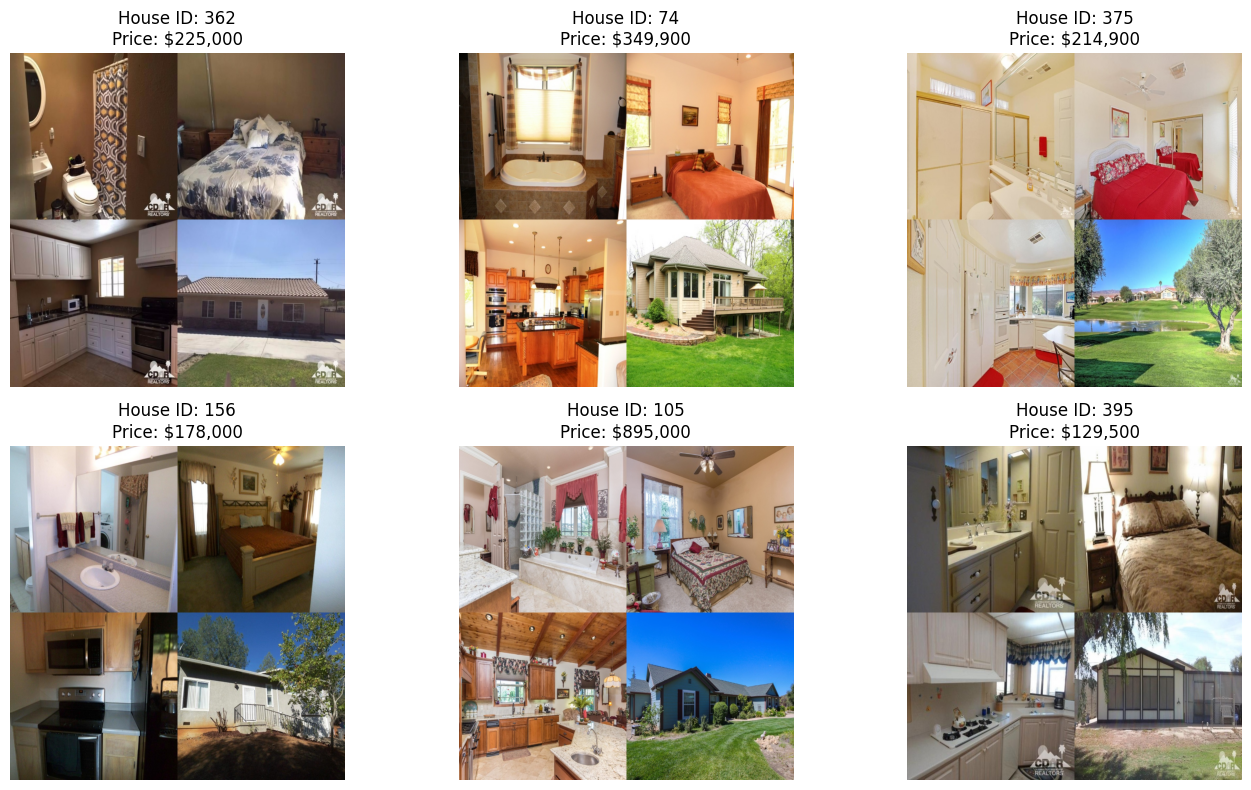

In [2]:
# Folder naam definieren
images_dir = Path('Train')

# Size en shape
print(f'Aantal rijen in metadata: {len(df)}')
print(f'Aantal kolommen: {df.shape[1]}')

# Enkele afbeeldingen dus we nemen 6 met fixed random state
sample_df = df.sample(6, random_state=42)

# Subplots maken
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# ID en prijs geven voor elke subplot
for ax, (_, row) in zip(axes, sample_df.iterrows()):

    # ID naar int en dan zoeken naar ID foto in Train folder
    house_id = int(row['House ID'])
    image_path = images_dir / f'{house_id}.jpg'

    # Foto inladen en laten zien met relevante info
    image = mpimg.imread(image_path)
    ax.imshow(image)
    ax.set_title(f"House ID: {house_id}\nPrice: ${row['Price']:,.0f}")

    ax.axis('off')

for ax in axes[len(sample_df):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Hier staan een voorbeeld van enkele huizen zoals ze voorkomen in de dataset. ID en prijs is erbij gezet per huis.

### 3.2 Metadata analyseren en relaties met targetvariabele onderzoeken

We onderzoeken de relatie tussen `Price` (target) en de andere variabelen via samenvattingen en visualisaties.


Ontbrekende waarden per kolom:


,missing_values
House ID,0
Bedrooms,0
Bathrooms,0
Area,0
Latitude,0
Longitude,0
Price,0



Beschrijvende statistiek:


,House ID,Bedrooms,Bathrooms,Area,Latitude,Longitude,Price
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,5.000000e+02
mean,250.500000,3.350000,2.669500,2369.64600,35.128844,-116.469049,5.980218e+05
std,144.481833,1.172283,1.017578,1208.18261,2.386173,6.554434,5.240649e+05
min,1.000000,1.000000,1.000000,701.00000,32.631500,-122.368300,2.200000e+04
25%,125.750000,2.000000,2.000000,1440.00000,33.808200,-119.802500,2.350000e+05
50%,250.500000,3.000000,2.500000,2097.50000,33.920800,-117.609600,5.300000e+05
75%,375.250000,4.000000,3.000000,3104.50000,35.640600,-116.371300,7.490000e+05
max,500.000000,10.000000,7.000000,9583.00000,47.791800,-87.885900,5.858000e+06


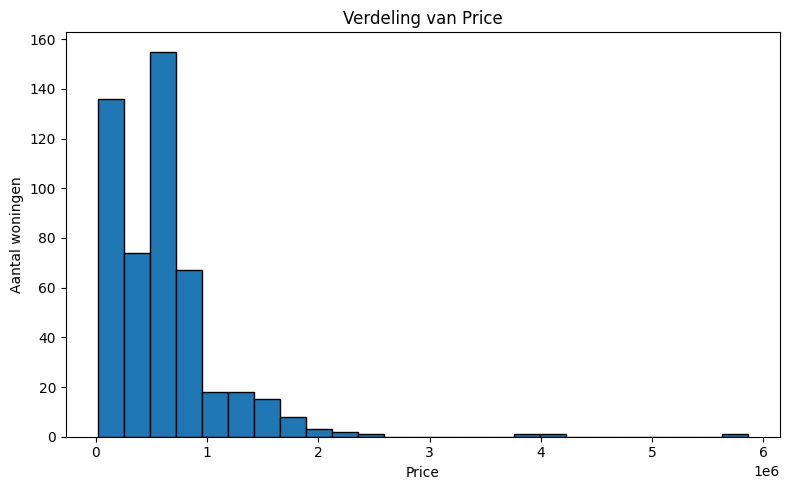

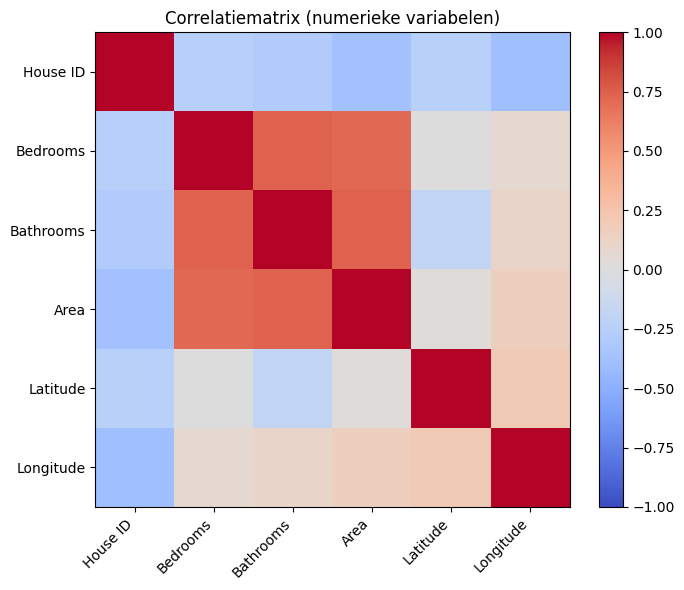

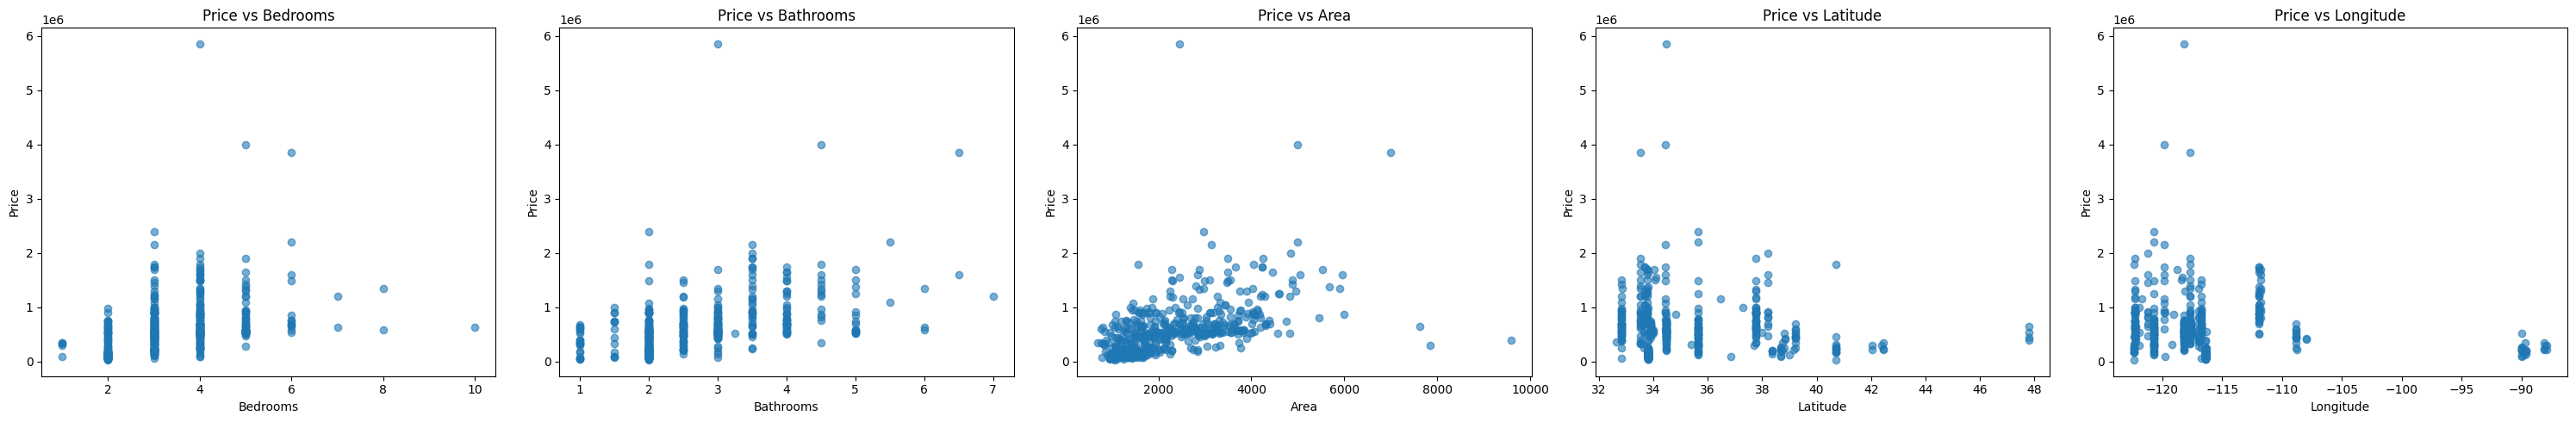

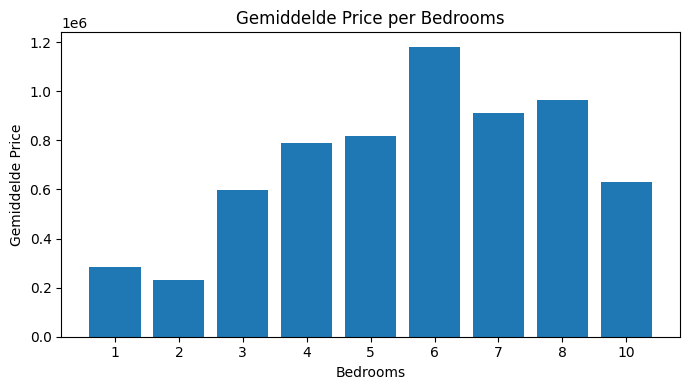

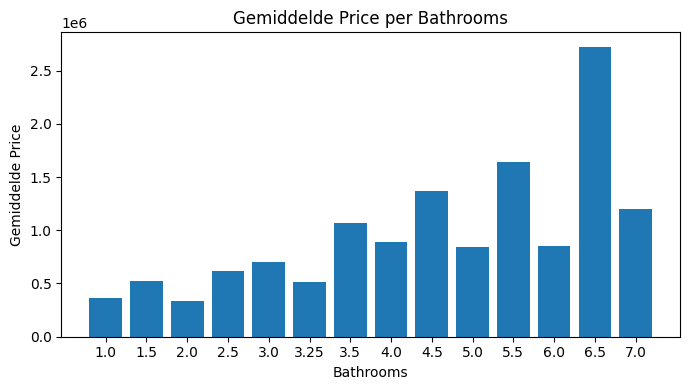

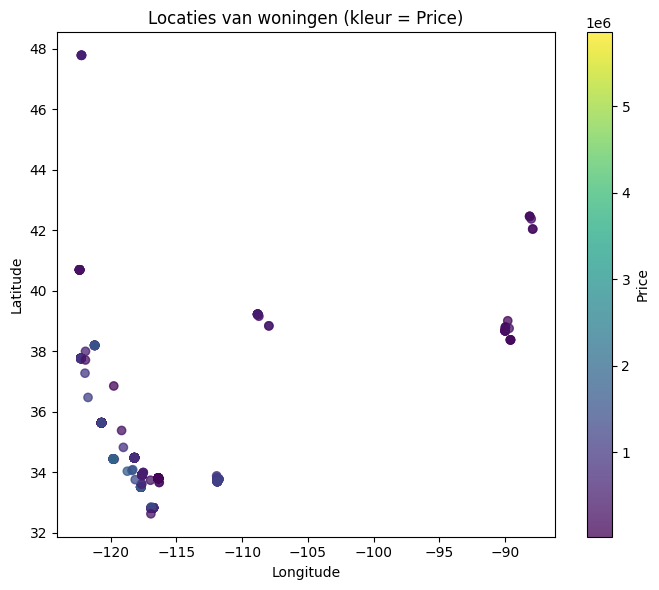

In [3]:
# We maken een lijst van de features (dus geen Price)
feature_cols = [col for col in df.columns if col != 'Price']

# We kijken of er ontbrekende waardes zijn en hoeveel
print('\nOntbrekende waarden per kolom:')
display(df.isna().sum().to_frame('missing_values'))

# Beschrijvende statistieken
print('\nBeschrijvende statistiek:')
display(df.describe(include='all'))

# We kijken naar de verdeling van de prijs
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['Price'], bins=25, edgecolor='black')
ax.set_title('Verdeling van Price')
ax.set_xlabel('Price')
ax.set_ylabel('Aantal woningen')
plt.tight_layout()
plt.show()

# We kijken naar correlaties tussen de features
corr = df[feature_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title('Correlatiematrix (numerieke variabelen)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

#Relatie Price vs elke feature (excl. House ID)
plot_features = [c for c in feature_cols if c not in ['Price', 'House ID']]

n = len(plot_features)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, plot_features):
    ax.scatter(df[col], df['Price'], alpha=0.6)
    ax.set_title(f'Price vs {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Price')

plt.tight_layout()
plt.show()

#Gemiddelde prijs per aantal slaapkamers/badkamers
for group_col in ['Bedrooms', 'Bathrooms']:
    if group_col in df.columns:
        grouped = df.groupby(group_col)['Price'].mean().sort_index()
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(grouped.index.astype(str), grouped.values)
        ax.set_title(f'Gemiddelde Price per {group_col}')
        ax.set_xlabel(group_col)
        ax.set_ylabel('Gemiddelde Price')
        plt.tight_layout()
        plt.show()

# Locatieplot (Latitude/Longitude) gekleurd op Price
if {'Latitude', 'Longitude', 'Price'}.issubset(df.columns):
    fig, ax = plt.subplots(figsize=(7, 6))
    scatter = ax.scatter(df['Longitude'], df['Latitude'], c=df['Price'], cmap='viridis', alpha=0.75)
    ax.set_title('Locaties van woningen (kleur = Price)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Price')
    plt.tight_layout()
    plt.show()

### 3.3 Bevindingen

Na het uitvoeren van de EDA zijn we tot bepaalde conclusies gekomen.

1. Huizen kunnen zo goedkoop zijn als `$22.000` en oplopen tot `$5.858.000` zoals we hebben gezien in de beschrijvende statistieken.
2. Over het algemeen zijn de prijzen van de huizen aan de lagere kant van het spectrum, zoals we hebben gezien in de rechtsscheve verdelingen van de prijzen. Dit betekent dat de echt dure huizen (Bijvoorbeeld die van $5.858.000) duidelijk outliers zijn en de prijzen over het algemeen dichter op elkaar zitten en steeds minder voorkomt hoe hoger de prijs stijgt.
3. Zoals te zien in de correlatiematrix zien we dat `Area`, `Bedrooms` en `Bathrooms` een sterke **positieve** correlatie hebben met elkaar.
4. Als we kijken naar de kleinere subplots en dan inzoomen op `Area vs. Price` zien we dat over het algemeen hoe lager de area is, hoe lager de prijs is, met enkele uitschieters.
5. Als laatst zien we in de location plot dat huizen met een lagere lat- en longitude een wat hogere prijs hebben dan de locaties die een hogere lat- of longitude hebben.

## 4 Fully connected neuraal netwerk

### 4.1 Keuzes en motivatie

Voor deze deelopdracht gebruiken we alleen de **tabulaire variabelen** (`Area`, `Bedrooms`, `Bathrooms`, `Latitude`, `Longitude`) en voorspellen we `Price` met een dense neuraal netwerk.

- **Aantal lagen / neuronen**: we kiezen een compact MLP met 3 hidden layers (`128 -> 64 -> 32`). Dit geeft genoeg capaciteit voor niet-lineaire relaties zonder het model onnodig groot te maken.
- **Activeringsfunctie**: `ReLU` in hidden layers, omdat deze stabiel traint en effectief is voor regressieproblemen met geschaalde features.
- **Outputlaag**: 1 neuron met lineaire activatie, omdat we een continue waarde (prijs) voorspellen.
- **Lossfunctie**: we kiezen **MSE** (`mean_squared_error`) als primaire loss, omdat grote fouten bij prijsvoorspelling extra moeten doorwegen. Daarnaast rapporteren we `MAE` en `RMSE` als interpreteerbare metrics.
- **Optimizer**: **Adam** (`learning_rate=1e-3`), een optimizer die per parameter een adaptieve learning rate gebruikt via exponentieel voortschrijdende gemiddelden van gradiënten (eerste en tweede moment), wat vaak snelle en stabiele convergentie geeft.
- **Epochs**: maximaal 150 epochs met `EarlyStopping`; zo krijgt het model voldoende leertijd, maar stopt het automatisch zodra de validatiefout niet meer verbetert.

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

!pip install tensorflow
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import plot_model

# Reproduceerbaarheid
tf.random.set_seed(42)
np.random.seed(42)

# Zorg dat df beschikbaar is
if 'df' not in globals():
    import pandas as pd
    df = pd.read_csv('train.csv')

# Alleen tabulaire features gebruiken
X = df.drop(columns=['Price', 'House ID'], errors='ignore').copy()
y = df['Price'].astype('float32').copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling voor stabielere NN training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Door scheve prijsverdeling trainen we op log-prijs
y_train_log = np.log1p(y_train.values)
y_val_log = np.log1p(y_val.values)

print(f'Train shape: {X_train_scaled.shape}, Validatie shape: {X_val_scaled.shape}')
print('Features gebruikt:', list(X.columns))


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\mario\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Train shape: (400, 5), Validatie shape: (100, 5)
Features gebruikt: ['Bedrooms', 'Bathrooms', 'Area', 'Latitude', 'Longitude']


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_128 (Dense)               │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price_output (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
visualisatie niet gelukt: installeer pydots en https://graphviz.gitlab.io/download/.


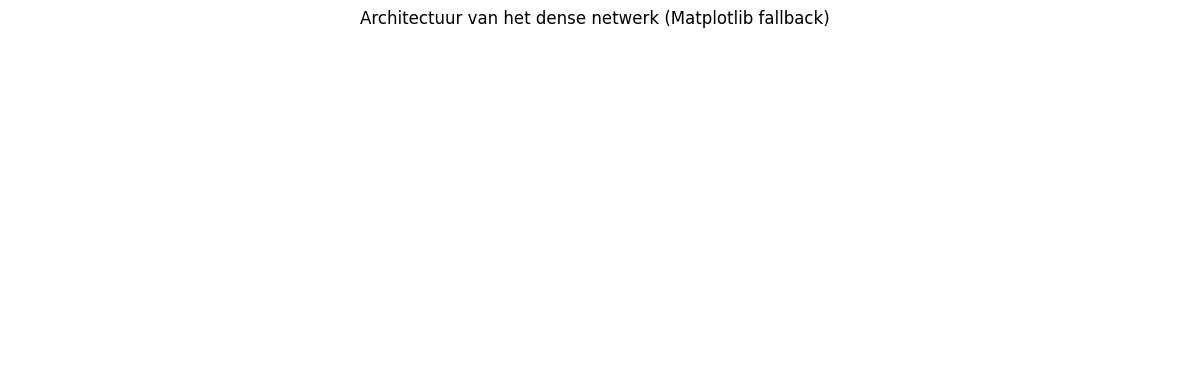

In [23]:
# Dense (fully-connected) regressiemodel
model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],), name='input_tabular'),
    layers.Dense(128, activation='relu', name='dense_128'),
    layers.Dense(64, activation='relu', name='dense_64'),
    layers.Dense(32, activation='relu', name='dense_32'),
    layers.Dense(1, activation='linear', name='price_output')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

model.summary()

# Architectuurplot opslaan en tonen
plot_path = Path('dense_model_architecture.png')

try:
    plot_model(
        model,
        to_file=str(plot_path),
        show_shapes=True,
        show_dtype=False,
        show_layer_names=True,
        dpi=120
    )
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(mpimg.imread(plot_path))
    ax.axis('off')
    ax.set_title('Architectuur van het dense netwerk (Keras plot_model)')
    plt.tight_layout()
    plt.show()
except Exception:
    print('visualisatie niet gelukt: installeer pydots en https://graphviz.gitlab.io/download/.')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('Architectuur van het dense netwerk (Matplotlib fallback)')
    plt.tight_layout()
    plt.show()

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 160.7562 - mae: 12.6400 - rmse: 12.6790 - val_loss: 142.1026 - val_mae: 11.8667 - val_rmse: 11.9207
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 134.3544 - mae: 11.5142 - rmse: 11.5911 - val_loss: 102.3018 - val_mae: 9.9457 - val_rmse: 10.1144
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 87.2995 - mae: 9.0286 - rmse: 9.3434 - val_loss: 46.1080 - val_mae: 6.1509 - val_rmse: 6.7903
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 37.0340 - mae: 5.3270 - rmse: 6.0856 - val_loss: 28.1570 - val_mae: 4.2560 - val_rmse: 5.3063
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 24.5233 - mae: 4.0754 - rmse: 4.9521 - val_loss: 21.1860 - val_mae: 3.6112 - val_rmse: 4.6028
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 17.4798 - mae: 3.4703 - rmse: 4.1809 - val_loss: 14.0862 - val_mae: 2.8267 - val_rmse: 3.7532
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 13.76

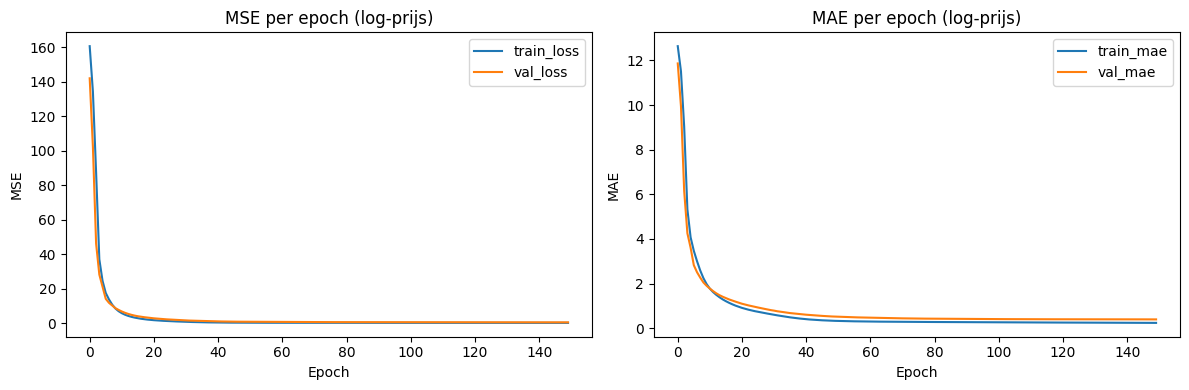

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Validatie MAE (prijs-schaal): $485,176.84
Validatie RMSE (prijs-schaal): $2,701,595.93
Totaal getrainde epochs: 150


In [6]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_log,
    validation_data=(X_val_scaled, y_val_log),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Leerproces visualiseren
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='train_loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].set_title('MSE per epoch (log-prijs)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history.history['mae'], label='train_mae')
axes[1].plot(history.history['val_mae'], label='val_mae')
axes[1].set_title('MAE per epoch (log-prijs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluatie op originele prijsschaal
val_pred_log = model.predict(X_val_scaled).reshape(-1)
val_pred_price = np.expm1(val_pred_log)
val_true_price = np.expm1(y_val_log)

val_mae_price = mean_absolute_error(val_true_price, val_pred_price)
val_rmse_price = np.sqrt(mean_squared_error(val_true_price, val_pred_price))

print(f'Validatie MAE (prijs-schaal): ${val_mae_price:,.2f}')
print(f'Validatie RMSE (prijs-schaal): ${val_rmse_price:,.2f}')
print(f'Totaal getrainde epochs: {len(history.history["loss"])}')

bron: https://campus.datacamp.com/courses/introduction-to-deep-learning-in-python/fine-tuning-keras-models?ex=6

## Convolutioneel neuraal netwerk from scratch 

In [7]:

# Map met afbeeldingen
image_folder = "Train"

# Maak pad naar afbeeldingen
df["image_path"] = df["House ID"].apply(lambda x: os.path.join(image_folder, f"{x}.jpg"))

nolabel = df[["House ID", "image_path", "Price"]]
# Controle
print(nolabel)



     House ID     image_path    Price
0           1    Train\1.jpg   869500
1           2    Train\2.jpg   865200
2           3    Train\3.jpg   889000
3           4    Train\4.jpg   910000
4           5    Train\5.jpg   971226
..        ...            ...      ...
495       496  Train\496.jpg   380000
496       497  Train\497.jpg   429900
497       498  Train\498.jpg   585000
498       499  Train\499.jpg   319000
499       500  Train\500.jpg  1495000

[500 rows x 3 columns]


In [8]:
print(nolabel.columns)

image_folder = "Train"

nolabel["image_path"] = nolabel["House ID"].apply(
    lambda x: os.path.join(image_folder, f"{x}.jpg")
)

print(os.listdir("Train")[:10])


# Maak een echte kopie
nolabel = nolabel.copy()

# Maak correcte image_path
nolabel["image_path"] = nolabel["House ID"].apply(
    lambda x: os.path.join("Train", f"{x}.jpg")
)

# Hernoem prijskolom
nolabel["price"] = nolabel["Price"]

# Alleen houden wat je nodig hebt
nolabel = nolabel[["image_path", "price"]]

print(nolabel.head())



Index(['House ID', 'image_path', 'Price'], dtype='object')
['1.jpg', '10.jpg', '100.jpg', '101.jpg', '102.jpg', '103.jpg', '104.jpg', '105.jpg', '106.jpg', '107.jpg']
    image_path   price
0  Train\1.jpg  869500
1  Train\2.jpg  865200
2  Train\3.jpg  889000
3  Train\4.jpg  910000
4  Train\5.jpg  971226


C:\Users\mario\AppData\Local\Temp\ipykernel_56520\1145214855.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nolabel["image_path"] = nolabel["House ID"].apply(


In [9]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print("Aantal train:", len(train_df))
print("Aantal validatie:", len(val_df))


Aantal train: 400
Aantal validatie: 100


In [10]:
# Split
train_df, val_df = train_test_split(nolabel, test_size=0.2, random_state=42)

print("Aantal train:", len(train_df))
print("Aantal validatie:", len(val_df))

# Instellingen
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Paden en labels
train_paths = train_df["image_path"].values
train_labels = train_df["price"].values

val_paths = val_df["image_path"].values
val_labels = val_df["price"].values

# Laadfunctie
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = image / 255.0
    return image, label

# Datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Aantal train: 400
Aantal validatie: 100


In [11]:
for images, labels in train_ds.take(1):
    print("Batch shape:", images.shape)
    print("Labels shape:", labels.shape)

Batch shape: (32, 128, 128, 3)
Labels shape: (32,)


Shape van 1 afbeelding: (128, 128, 3)
Prijs: 529900


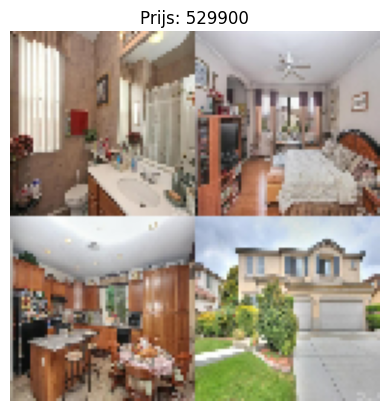

In [12]:
for images, labels in train_ds.take(1):
    image = images[0]
    label = labels[0]

print("Shape van 1 afbeelding:", image.shape)
print("Prijs:", label.numpy())

plt.imshow(image.numpy())
plt.title(f"Prijs: {label.numpy():.0f}")
plt.axis("off")
plt.show()

In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

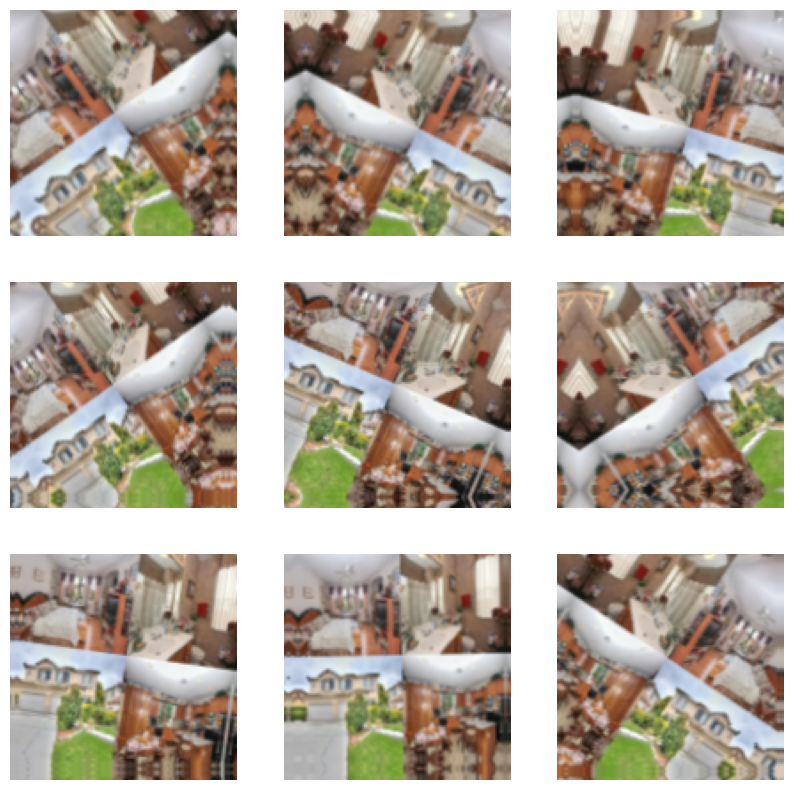

In [14]:
for images, labels in train_ds.take(1):
    image = images[0]

plt.figure(figsize=(10, 10))

for i in range(9):
    augmented = data_augmentation(tf.expand_dims(image, 0))
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented[0].numpy())
    plt.axis("off")

plt.show()

In [15]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="linear")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,296,897 (16.39 MB)

 Trainable params: 4,296,449 (16.39 MB)

 Non-trainable params: 448 (1.75 KB)

## 5 Transfer learning

In deze opdracht gebruiken we alleen de **afbeeldingen** en de bijbehorende **prijslabels**.

We kiezen voor **MobileNetV2** als vooraf getraind visionmodel met gewichten van **ImageNet**. Daarna fine-tunen we het model op de woningafbeeldingen.

### 5.1 Waarom een vooraf getraind model?

**Gekozen architectuur**: MobileNetV2  
**Vooraf getraind op**: ImageNet

Voordelen van pretrained visionmodellen:
1. Ze starten al met sterke algemene beeldfeatures (randen, texturen, vormen), waardoor minder data nodig is.
2. Ze convergeren sneller dan vanaf nul trainen.
3. Ze generaliseren vaak beter op kleine/middelgrote datasets.
4. Ze zijn efficiënter: je hoeft alleen een relatief kleine regressie-head te trainen en daarna beperkt te fine-tunen.

Deze keuzes sluiten aan bij transfer-learning methodieken zoals besproken in DataCamp deep learning tutorials.

In [16]:
# Reproduceerbaarheid
tf.random.set_seed(42)
np.random.seed(42)

# Alleen afbeeldingen + label gebruiken
df['image_path'] = df['House ID'].apply(lambda x: os.path.join('Train', f'{x}.jpg'))
df = df[['image_path', 'Price']].copy()

# Train/validatie split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Log voor stabielere regressietraining
train_targets_log = np.log1p(train_df['Price'].astype('float32').values)
val_targets_log = np.log1p(val_df['Price'].astype('float32').values)

train_paths_tl = train_df['image_path'].values
val_paths_tl = val_df['image_path'].values

# We zetten hier IMG en batch size vast want we gebruiken heeeel veel
IMG_SIZE = 160
BATCH_SIZE = 32

def load_image_for_tl(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)  # houd schaal 0-255 voor MobileNet preprocess
    return image, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), reshuffle_each_iteration=True)
    ds = ds.map(load_image_for_tl, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

transfer_train_ds = make_dataset(train_paths_tl, train_targets_log, training=True)
transfer_val_ds = make_dataset(val_paths_tl, val_targets_log, training=False)

# Prints om het mooi te maken
print(f'Aantal train samples: {len(train_df)}')
print(f'Aantal validatie samples: {len(val_df)}')

Aantal train samples: 400
Aantal validatie samples: 100


Model: "mobilenetv2_transfer_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_tl            │ (None, 160, 160, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price_output (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
installeer pydots en https://graphviz.gitlab.io/download/.


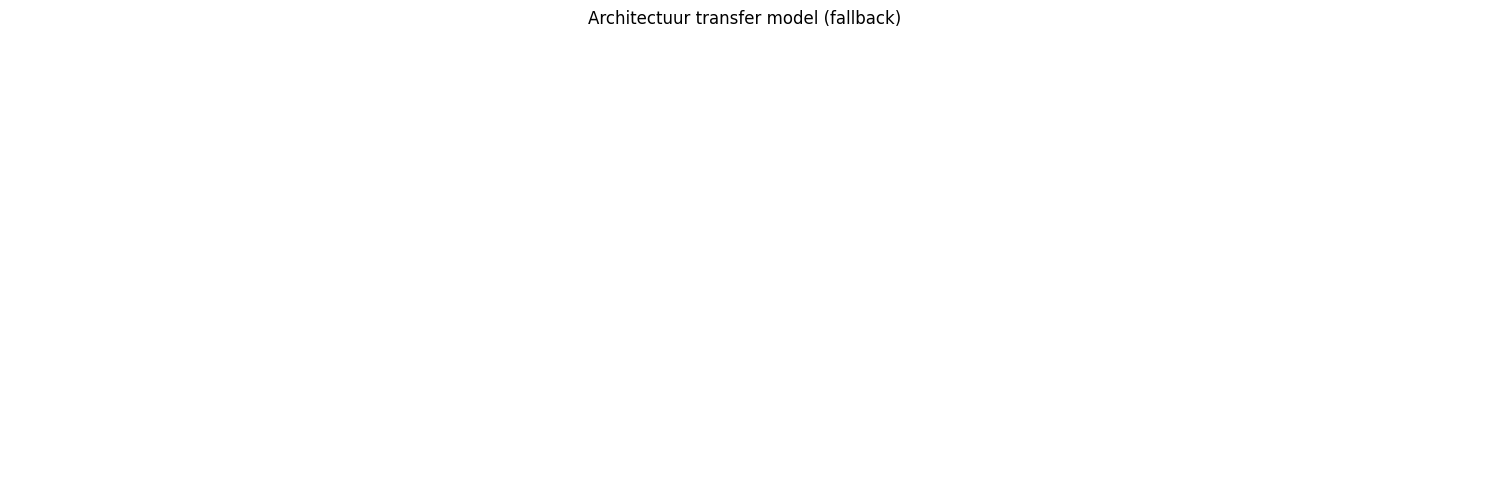

In [22]:
# Data augmentation voor robuustheid
data_augmentation_tl = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.08, 0.08),
], name='data_augmentation_tl')

# Vooraf getrainde backbone
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Regressiemodel op basis van transfer learning
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
x = data_augmentation_tl(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
x = layers.Dropout(0.30, name='dropout_1')(x)
x = layers.Dense(128, activation='relu', name='dense_128')(x)
x = layers.Dropout(0.20, name='dropout_2')(x)
outputs = layers.Dense(1, activation='linear', name='price_output')(x)

transfer_model = models.Model(inputs, outputs, name='mobilenetv2_transfer_regression')

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

transfer_model.summary()

# Architectuur visualiseren
plot_path_tl = Path('transfer_mobilenetv2_architecture.png')

try:
    plot_model(
        transfer_model,
        to_file=str(plot_path_tl),
        show_shapes=True,
        show_dtype=False,
        show_layer_names=True,
        dpi=120
    )
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.imshow(mpimg.imread(plot_path_tl))
    ax.axis('off')
    ax.set_title('Architectuur transfer model: MobileNetV2 + regressie-head')
    plt.tight_layout()
    plt.show()
except Exception:
    print('visualisatie niet gelukt: installeer pydots en https://graphviz.gitlab.io/download/.')

### 5.2 Fine-tuning stappen 

We zullen twee stappen ondernemen:

1. **Stap 1 (feature extractor)**
   - De volledige MobileNetV2-backbone staat op `trainable = False`.
   - Alleen de nieuwe regressie-head wordt getraind.
   - Doel: stabiel leren op taak-specifieke output zonder pretrained gewichten direct te verstoren.

2. **Stap 2 (fine-tuning)**
   - De backbone wordt deels geunfreezed: alleen de laatste lagen mogen mee updaten.
   - BatchNormalization lagen houden we frozen voor stabielere training.
   - Learning rate wordt verlaagd voor kleine, gecontroleerde updates.

**Nieuw toegevoegde lagen in de head**:
1. `GlobalAveragePooling2D`: comprimeert featuremaps naar een compacte vector.
2. `Dropout(0.30)`: regularisatie tegen overfitting.
3. `Dense(128, relu)`: leert taak-specifieke regressiepatronen.
4. `Dropout(0.20)`: extra regularisatie.
5. `Dense(1, linear)`: continue prijsvoorspelling (regressie-output).

In [24]:
# Stap 1: alleen de nieuwe head trainen
early_stop_tl = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr_tl = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history_tl_frozen = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=25,
    callbacks=[early_stop_tl, reduce_lr_tl],
    verbose=1
)

Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 504ms/step - loss: 39.6411 - mae: 4.8415 - rmse: 6.2961 - val_loss: 4.1757 - val_mae: 1.7567 - val_rmse: 2.0435 - learning_rate: 0.0010
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 313ms/step - loss: 8.5857 - mae: 2.4311 - rmse: 2.9301 - val_loss: 6.8768 - val_mae: 2.1717 - val_rmse: 2.6224 - learning_rate: 0.0010
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 342ms/step - loss: 5.5690 - mae: 1.9041 - rmse: 2.3599 - val_loss: 2.6659 - val_mae: 1.3471 - val_rmse: 1.6328 - learning_rate: 0.0010
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 344ms/step - loss: 4.2895 - mae: 1.6734 - rmse: 2.0711 - val_loss: 2.1428 - val_mae: 1.0976 - val_rmse: 1.4638 - learning_rate: 0.0010
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 360ms/step - loss: 3.8059 - mae: 1.5983 - rmse: 1.9509 - val_loss: 2.0353 - val_mae: 1.1274 - val_rmse: 1.4266 - learning_rate: 0.0010
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 348ms/step - loss: 3.9799 - mae: 1.5990 - rmse: 1.9950 - val_loss: 2.3026 - v

In [19]:
# Stap 2 fine-tune alleen de laatste lagen van MobileNetV2
base_model.trainable = True

# Alleen de laatste 30 lagen unfreezen
for layer in base_model.layers[:-30]:
    layer.trainable = False

# BatchNorm-lagen frozen houden voor trainingsstabiliteit
for layer in base_model.layers[-30:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(int(layer.trainable) for layer in base_model.layers)
print(f'Trainable lagen in backbone tijdens fine-tuning: {trainable_count}/{len(base_model.layers)}')

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='mse',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

history_tl_finetune = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=20,
    callbacks=[early_stop_tl, reduce_lr_tl],
    verbose=1
)


Trainable lagen in backbone tijdens fine-tuning: 19/154
Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 457ms/step - loss: 2.9134 - mae: 1.3510 - rmse: 1.7069 - val_loss: 2.9834 - val_mae: 1.4962 - val_rmse: 1.7272 - learning_rate: 1.0000e-05
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 314ms/step - loss: 3.1454 - mae: 1.4223 - rmse: 1.7735 - val_loss: 2.5033 - val_mae: 1.3474 - val_rmse: 1.5822 - learning_rate: 1.0000e-05
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 308ms/step - loss: 2.8195 - mae: 1.3767 - rmse: 1.6791 - val_loss: 2.1348 - val_mae: 1.2129 - val_rmse: 1.4611 - learning_rate: 1.0000e-05
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - loss: 2.9042 - mae: 1.3745 - rmse: 1.7038
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 303ms/step - loss: 2.7997 - mae: 1.3391 - rmse: 1.6732 - val_loss: 2.8352 - val_mae: 1.4548 - val_rmse: 1.6838 - learning_rate: 1.0000e-05
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 322ms/step - loss: 2.

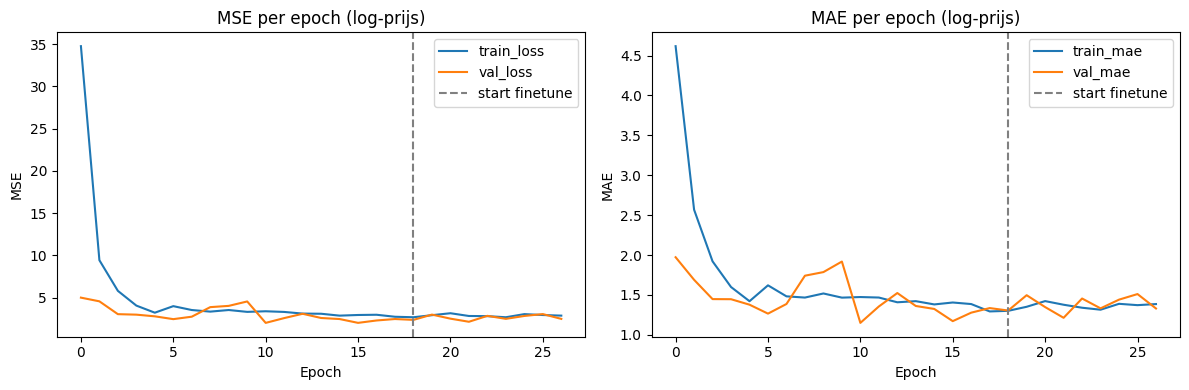

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step
Validatie MSE (prijs-schaal): 361,627,090,944.00
Validatie MAE (prijs-schaal): $440,481.28
Validatie RMSE (prijs-schaal): $601,354.38


In [ ]:
# Leercurves voor beide fases
frozen_loss = history_tl_frozen.history['loss']
frozen_val_loss = history_tl_frozen.history['val_loss']
finetune_loss = history_tl_finetune.history['loss']
finetune_val_loss = history_tl_finetune.history['val_loss']

frozen_mae = history_tl_frozen.history['mae']
frozen_val_mae = history_tl_frozen.history['val_mae']
finetune_mae = history_tl_finetune.history['mae']
finetune_val_mae = history_tl_finetune.history['val_mae']

all_loss = frozen_loss + finetune_loss
all_val_loss = frozen_val_loss + finetune_val_loss
all_mae = frozen_mae + finetune_mae
all_val_mae = frozen_val_mae + finetune_val_mae

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(all_loss, label='train_loss')
axes[0].plot(all_val_loss, label='val_loss')
axes[0].axvline(len(frozen_loss) - 1, color='gray', linestyle='--', label='start finetune')
axes[0].set_title('MSE per epoch (log-prijs)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(all_mae, label='train_mae')
axes[1].plot(all_val_mae, label='val_mae')
axes[1].axvline(len(frozen_mae) - 1, color='gray', linestyle='--', label='start finetune')
axes[1].set_title('MAE per epoch (log-prijs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluatie op originele prijsschaal
val_pred_log = transfer_model.predict(transfer_val_ds).reshape(-1)
val_pred_price = np.expm1(val_pred_log)
val_true_price = np.expm1(val_targets_log)

val_mse_price = mean_squared_error(val_true_price, val_pred_price)
val_mae_price = mean_absolute_error(val_true_price, val_pred_price)
val_rmse_price = np.sqrt(val_mse_price)

print(f'MSE: ${val_mse_price:,.2f}')
print(f'MAE: ${val_mae_price:,.2f}')
print(f'RMSE: ${val_rmse_price:,.2f}')

### 5.3 Motivatie van extra technieken

Gekozen technieken en motivatie:
1. **Data augmentation** (`RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomTranslation`) om overfitting te verminderen en variatie in beelden te simuleren.
2. **Dropout** in de regressie-head om co-adaptatie van neuronen te beperken.
3. **EarlyStopping** om te stoppen zodra validatiefout niet meer verbetert.
4. **ReduceLROnPlateau** om automatisch kleinere stappen te nemen bij stagnatie.
5. **Log-transformatie van target** (`log1p`) omdat woningprijzen vaak scheef verdeeld zijn; dit stabiliseert optimalisatie.
6. **Gefaseerd fine-tunen**: eerst alleen head, daarna alleen laatste backbone-lagen met lage learning rate voor gecontroleerde domeinadaptatie.

### 5.4 Bron

Methodes zijn gebasseerd op het volgende:  
- https://www.datacamp.com/fr/tutorial/deep-learning-python
- https://codelabs.developers.google.com/codelabs/keras-flowers-transfer-learning#3


## 6 Multimodaal model

In deze sectie bouwen we een **multimodaal regressiemodel** dat **2D-beelddata** (woningfoto's) en **1D-tabulaire metadata** (woningkenmerken) parallel verwerkt.

We gebruiken:
- een **CNN-branch** met transfer learning (MobileNetV2)
- een **Dense-branch** voor de metadata
- **late fusion** via concatenatie

Daarna trainen en evalueren we het model met **MAE op prijsschaal** als hoofdmetric.

### 6.1 Prep

In [ ]:
# We laden DF OPNIEUW in omdat we eerder met DF dingen hebben verandert
df = pd.read_csv('train.csv')

#---- Dit stukje is gefixed met built-in Copilot ----
# Pad woningen
df['image_path'] = df['House ID'].apply(lambda x: os.path.join('Train', f'{x}.jpg'))

# Houd alleen rijen met bestaande afbeelding over
mask_exists = df['image_path'].apply(os.path.exists)
missing_images = int((~mask_exists).sum())
if missing_images > 0:
    print(f'Waarschuwing: {missing_images} rijen zonder afbeelding worden verwijderd.')

df = df.loc[mask_exists].copy()
#---- Einde ---

# Features
exclude_cols = ['House ID', 'Price']
feature_cols = [c for c in df.columns if c not in exclude_cols + ['image_path'] and np.issubdtype(df[c].dtype, np.number)]

# Train / Validatie
mm_train_df, mm_val_df = train_test_split(df, test_size=0.2, random_state=42)

# Log schaal tagets
mm_y_train_log = np.log1p(mm_train_df['Price'].astype('float32').values)
mm_y_val_log = np.log1p(mm_val_df['Price'].astype('float32').values)

# Fit transform
mm_scaler = StandardScaler()
mm_X_train = mm_scaler.fit_transform(mm_train_df[feature_cols].astype('float32'))
mm_X_val = mm_scaler.transform(mm_val_df[feature_cols].astype('float32'))

# Afbeeldingspaden
mm_train_paths = mm_train_df['image_path'].values
mm_val_paths = mm_val_df['image_path'].values

print(f'Aantal train samples: {len(mm_train_df)}')
print(f'Aantal validatie samples: {len(mm_val_df)}')
print(f'Aantal metadata-features: {len(feature_cols)} -> {feature_cols}')

Aantal train samples: 400
Aantal validatie samples: 100
Aantal metadata-features: 5 -> ['Bedrooms', 'Bathrooms', 'Area', 'Latitude', 'Longitude']


(Copilot Auto mode, 2026)

### 6.2 Multimodale tf.data pipeline

In [ ]:

MM_IMG_SIZE = 160
MM_BATCH_SIZE = 32

# Gebruik dezelfde stijl van augmentatie als in sectie 5.
data_augmentation_mm = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.08, 0.08),
], name='data_augmentation_mm')

def load_multimodal_sample(path, tabular, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [MM_IMG_SIZE, MM_IMG_SIZE])
    image = tf.cast(image, tf.float32)  # schaal 0-255; preprocess_input zit in model
    tabular = tf.cast(tabular, tf.float32)
    label = tf.cast(label, tf.float32)
    return (image, tabular), label

def make_multimodal_dataset(paths, tabular, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, tabular, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), reshuffle_each_iteration=True)
    ds = ds.map(load_multimodal_sample, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(MM_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

mm_train_ds = make_multimodal_dataset(mm_train_paths, mm_X_train, mm_y_train_log, training=True)
mm_val_ds = make_multimodal_dataset(mm_val_paths, mm_X_val, mm_y_val_log, training=False)


for (image_batch, tabular_batch), label_batch in mm_train_ds.take(1):
    print('Image batch shape   :', image_batch.shape)
    print('Tabular batch shape :', tabular_batch.shape)
    print('Label batch shape   :', label_batch.shape)

Image batch shape   : (32, 160, 160, 3)
Tabular batch shape : (32, 5)
Label batch shape   : (32,)


###  6.3 Multimodale architectuur:

Model: "multimodal_mobilenetv2_regression"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation_… │ (None, 160, 160,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_2       │ (None, 160, 160,  │          0 │ data_augmentatio… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_2          │ (None, 160, 160,  │          0 │ true_divide_2[0]… │
│ (Subtract)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 5, 5,      │  2,257,984 │ subtract_2[0][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_gap           │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dense_64        │ (None, 64)        │        384 │ tabular_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dropout       │ (None, 1280)      │          0 │ image_gap[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dropout         │ (None, 64)        │          0 │ tab_dense_64[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dense_128     │ (None, 128)       │    163,968 │ image_dropout[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dense_32        │ (None, 32)        │      2,080 │ tab_dropout[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ late_fusion_concat  │ (None, 160)       │          0 │ image_dense_128[… │
│ (Concatenate)       │                   │            │ tab_dense_32[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ post_fusion_dense_… │ (None, 128)       │     20,608 │ late_fusion_conc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ post_fusion_dropout │ (None, 128)       │          0 │ post_fusion_dens… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ post_fusion_dense_… │ (None, 32)        │      4,128 │ post_fusion_drop… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ price_output        │ (None, 1)         │         33 │ post_fusion_dens

 Total params: 2,449,185 (9.34 MB)

 Trainable params: 191,201 (746.88 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
visualisatie niet gelukt: installeer pydots en https://graphviz.gitlab.io/download/.


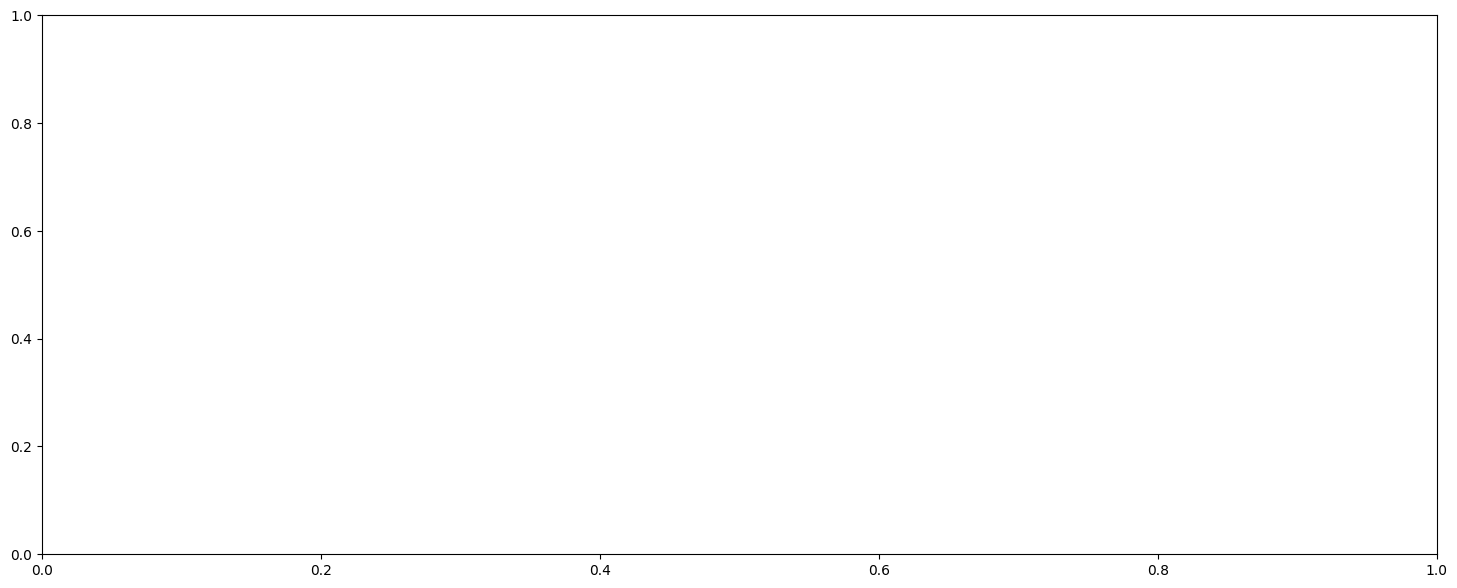

In [ ]:
#image branch + metadata branch
mm_image_input = layers.Input(shape=(MM_IMG_SIZE, MM_IMG_SIZE, 3), name='image_input')
mm_x_img = data_augmentation_mm(mm_image_input)
mm_x_img = tf.keras.applications.mobilenet_v2.preprocess_input(mm_x_img)

mm_base_model = tf.keras.applications.MobileNetV2(
    input_shape=(MM_IMG_SIZE, MM_IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
mm_base_model.trainable = False

mm_x_img = mm_base_model(mm_x_img, training=False)
mm_x_img = layers.GlobalAveragePooling2D(name='image_gap')(mm_x_img)
mm_x_img = layers.Dropout(0.30, name='image_dropout')(mm_x_img)
mm_x_img = layers.Dense(128, activation='relu', name='image_dense_128')(mm_x_img)

# MLP
mm_tab_input = layers.Input(shape=(len(feature_cols),), name='tabular_input')
mm_x_tab = layers.Dense(64, activation='relu', name='tab_dense_64')(mm_tab_input)
mm_x_tab = layers.Dropout(0.20, name='tab_dropout')(mm_x_tab)
mm_x_tab = layers.Dense(32, activation='relu', name='tab_dense_32')(mm_x_tab)

# Late fusion via concatenatie
mm_fused = layers.Concatenate(name='late_fusion_concat')([mm_x_img, mm_x_tab])

# Gezamenlijke regressie-head na fusie
mm_x = layers.Dense(128, activation='relu', name='post_fusion_dense_128')(mm_fused)
mm_x = layers.Dropout(0.25, name='post_fusion_dropout')(mm_x)
mm_x = layers.Dense(32, activation='relu', name='post_fusion_dense_32')(mm_x)
mm_output = layers.Dense(1, activation='linear', name='price_output')(mm_x)

multimodal_model = models.Model(
    inputs=[mm_image_input, mm_tab_input],
    outputs=mm_output,
    name='multimodal_mobilenetv2_regression'
)

multimodal_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

multimodal_model.summary()

# Architectuur visualiseren met dezelfde tool als H5
plot_path_mm = Path('multimodal_mobilenetv2_architecture.png')

try:
    plot_model(
        multimodal_model,
        to_file=str(plot_path_mm),
        show_shapes=True,
        show_dtype=False,
        show_layer_names=True,
        dpi=120
    )
    fig, ax = plt.subplots(figsize=(18, 7))
    ax.imshow(mpimg.imread(plot_path_mm))
    ax.axis('off')
    ax.set_title('Architectuur multimodaal model: MobileNetV2 + metadata MLP + late fusion')
    plt.tight_layout()
    plt.show()
except Exception:
    print('visualisatie niet gelukt: installeer pydots en https://graphviz.gitlab.io/download/.')

### 6.4 Laagentellingen voor rapportage

In [ ]:

conv_like_layers = sum(isinstance(layer, (layers.Conv2D, layers.DepthwiseConv2D)) for layer in mm_base_model.layers)
pool_layers = sum(isinstance(layer, (layers.MaxPooling2D, layers.AveragePooling2D, layers.GlobalAveragePooling2D)) for layer in mm_base_model.layers)

tab_dense_layers = 2
post_fusion_dense_layers_excl_output = 2
post_fusion_dense_layers_incl_output = 3

print(f'Convolutionele lagen in image branch (MobileNetV2 backbone): {conv_like_layers}')
print(f'Pooling lagen in image branch (in backbone): {pool_layers}')
print(f'Dense lagen in metadata branch: {tab_dense_layers}')
print('Combinatiestrategie van takken: late fusion via Concatenate')
print(f'Dense lagen na fusie (excl. output): {post_fusion_dense_layers_excl_output}')
print(f'Dense lagen na fusie (incl. output): {post_fusion_dense_layers_incl_output}')

Convolutionele lagen in image branch (MobileNetV2 backbone): 52
Pooling lagen in image branch (in backbone): 0
Dense lagen in metadata branch: 2
Combinatiestrategie van takken: late fusion via Concatenate
Dense lagen na fusie (excl. output): 2
Dense lagen na fusie (incl. output): 3


### 6.5 Training 


In [29]:
mm_early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

mm_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history_mm_frozen = multimodal_model.fit(
    mm_train_ds,
    validation_data=mm_val_ds,
    epochs=25,
    callbacks=[mm_early_stop, mm_reduce_lr],
    verbose=1
)

Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 522ms/step - loss: 35.4512 - mae: 4.7662 - rmse: 5.9541 - val_loss: 7.7098 - val_mae: 2.4813 - val_rmse: 2.7767 - learning_rate: 0.0010
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 351ms/step - loss: 8.5411 - mae: 2.3309 - rmse: 2.9225 - val_loss: 2.5448 - val_mae: 1.2470 - val_rmse: 1.5952 - learning_rate: 0.0010
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 372ms/step - loss: 4.9617 - mae: 1.7577 - rmse: 2.2275 - val_loss: 2.2996 - val_mae: 1.2422 - val_rmse: 1.5164 - learning_rate: 0.0010
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 329ms/step - loss: 4.5332 - mae: 1.7171 - rmse: 2.1291 - val_loss: 2.1932 - val_mae: 1.1956 - val_rmse: 1.4809 - learning_rate: 0.0010
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 318ms/step - loss: 4.3018 - mae: 1.5816 - rmse: 2.0741 - val_loss: 2.3883 - val_mae: 1.2849 - val_rmse: 1.5454 - learning_rate: 0.0010
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - loss: 3.6940 - mae: 1.5958 - rmse: 1.9220 - val_loss: 2.8689 - v

### 6.6 Fine-tuning


In [30]:
mm_base_model.trainable = True

# Alleen laatste 30 lagen unfreezen
for layer in mm_base_model.layers[:-30]:
    layer.trainable = False

# BatchNorm-lagen frozen houden voor stabiliteit
for layer in mm_base_model.layers[-30:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

mm_trainable_count = sum(int(layer.trainable) for layer in mm_base_model.layers)
print(f'Trainable lagen in backbone tijdens fine-tuning: {mm_trainable_count}/{len(mm_base_model.layers)}')

multimodal_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='mse',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

history_mm_finetune = multimodal_model.fit(
    mm_train_ds,
    validation_data=mm_val_ds,
    epochs=15,
    callbacks=[mm_early_stop, mm_reduce_lr],
    verbose=1
)

Trainable lagen in backbone tijdens fine-tuning: 19/154
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 481ms/step - loss: 3.0156 - mae: 1.3941 - rmse: 1.7365 - val_loss: 2.8967 - val_mae: 1.4420 - val_rmse: 1.7020 - learning_rate: 1.0000e-05
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - loss: 3.0455 - mae: 1.4200 - rmse: 1.7451 - val_loss: 4.2014 - val_mae: 1.7932 - val_rmse: 2.0497 - learning_rate: 1.0000e-05
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 379ms/step - loss: 2.7706 - mae: 1.3257 - rmse: 1.6645 - val_loss: 3.4923 - val_mae: 1.6104 - val_rmse: 1.8688 - learning_rate: 1.0000e-05
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - loss: 2.6960 - mae: 1.3134 - rmse: 1.6414
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 359ms/step - loss: 2.6869 - mae: 1.3186 - rmse: 1.6392 - val_loss: 3.4617 - val_mae: 1.6042 - val_rmse: 1.8606 - learning_rate: 1.0000e-05
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 385ms/step - loss: 2.

### 6.7 Evaluatie


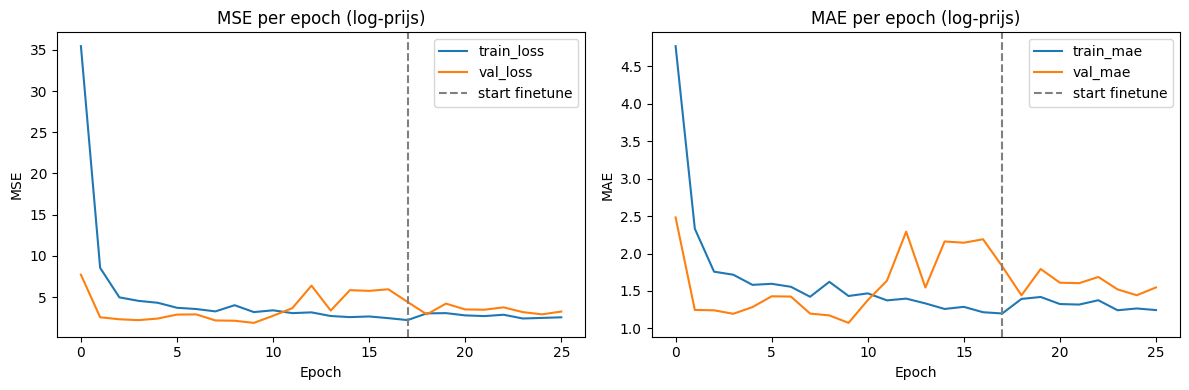

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step
Validatie MAE (prijsschaal): $439,680.53
Validatie MSE (prijsschaal): 399,135,309,824.00
Validatie RMSE (prijsschaal): $631,771.56


In [ ]:
mm_frozen_loss = history_mm_frozen.history['loss']
mm_frozen_val_loss = history_mm_frozen.history['val_loss']
mm_frozen_mae = history_mm_frozen.history['mae']
mm_frozen_val_mae = history_mm_frozen.history['val_mae']

if 'history_mm_finetune' in globals():
    mm_finetune_loss = history_mm_finetune.history['loss']
    mm_finetune_val_loss = history_mm_finetune.history['val_loss']
    mm_finetune_mae = history_mm_finetune.history['mae']
    mm_finetune_val_mae = history_mm_finetune.history['val_mae']

    mm_all_loss = mm_frozen_loss + mm_finetune_loss
    mm_all_val_loss = mm_frozen_val_loss + mm_finetune_val_loss
    mm_all_mae = mm_frozen_mae + mm_finetune_mae
    mm_all_val_mae = mm_frozen_val_mae + mm_finetune_val_mae
    mm_split_epoch = len(mm_frozen_loss) - 1
else:
    mm_all_loss = mm_frozen_loss
    mm_all_val_loss = mm_frozen_val_loss
    mm_all_mae = mm_frozen_mae
    mm_all_val_mae = mm_frozen_val_mae
    mm_split_epoch = None

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mm_all_loss, label='train_loss')
axes[0].plot(mm_all_val_loss, label='val_loss')
if mm_split_epoch is not None:
    axes[0].axvline(mm_split_epoch, color='gray', linestyle='--', label='start finetune')
axes[0].set_title('MSE per epoch (log-prijs)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(mm_all_mae, label='train_mae')
axes[1].plot(mm_all_val_mae, label='val_mae')
if mm_split_epoch is not None:
    axes[1].axvline(mm_split_epoch, color='gray', linestyle='--', label='start finetune')
axes[1].set_title('MAE per epoch (log-prijs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

# Eval
mm_val_pred_log = multimodal_model.predict(mm_val_ds).reshape(-1)
mm_val_pred_price = np.expm1(mm_val_pred_log)
mm_val_true_price = np.expm1(mm_y_val_log)

mm_val_mse_price = mean_squared_error(mm_val_true_price, mm_val_pred_price)
mm_val_mae_price = mean_absolute_error(mm_val_true_price, mm_val_pred_price)
mm_val_rmse_price = np.sqrt(mm_val_mse_price)

print(f'MAE): ${mm_val_mae_price:,.2f}')
print(f'MSE: ${mm_val_mse_price:,.2f}')
print(f'RMSE: ${mm_val_rmse_price:,.2f}')

### 6.8 Keuzes en verantwoording

**Tak 1 (beeld, CNN met transfer learning)**
- We gebruiken **MobileNetV2** als backbone (voorgetraind op ImageNet) met `include_top=False`.
- De backbone bevat veel convolutionele lagen (inclusief depthwise convolutions).
- Daarna volgt `GlobalAveragePooling2D` en een kleine Dense-head voor de regressie.

**Tak 2 (metadata, 1D tabulaire input)**
- Deze tak heeft **2 Dense-lagen** (`64 -> 32`).
- Motivatie: tabulaire features zijn laag-dimensionaal; een compacte MLP beperkt overfitting.

**Combinatiestrategie**
- We combineren beide takken met **late fusion via `Concatenate`**.
- Motivatie: beeld en metadata worden eerst apart verwerkt en daarna samengevoegd.

**Dense-lagen na fusie**
- Na de fusie gebruiken we **2 Dense-lagen** (`128 -> 32`) plus een lineaire outputlaag (`Dense(1)`).
- Dus: **2 Dense-lagen (excl. output)** of **3 inclusief output**.

**Waarom transfer learning hier passend is**
- Voor woningbeelden levert een ImageNet-gepretrainde backbone meestal snellere convergentie en betere generalisatie dan vanaf nul trainen. (TL Pros cons, 2021)
- We trainen gefaseerd: eerst frozen backbone, daarna optioneel fine-tunen van de laatste lagen met lage learning rate en BN-lagen frozen voor stabiliteit.

**Regularisatie en optimalisatie**
- Data augmentation (flip/rotatie/zoom/translatie) om variatie te simuleren.
- Dropout in meerdere delen van het model tegen overfitting.
- EarlyStopping om te stoppen bij uitblijvende validatieverbetering.
- ReduceLROnPlateau om learning rate automatisch te verlagen bij stagnatie.
- `log1p` target-transformatie omdat prijsverdelingen vaak scheef zijn; dit stabiliseert regressietraining.

## Bronnen
Bronnen:  
- https://keras.io/guides/transfer_learning/  
- https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV2  
- https://www.tensorflow.org/guide/keras/functional_api  
- https://pyimagesearch.com/2019/02/04/keras-multiple-inputs-and-mixed-data/
- https://www.tensorflow.org/tutorials/images/data_augmentation  
- https://keras.io/api/layers/preprocessing_layers/image_augmentation/
- https://keras.io/api/callbacks/early_stopping/  
- https://keras.io/api/callbacks/reduce_lr_on_plateau/
- https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics  
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html
- Microsoft Visual Studio Code in-chat agent (Auto)
- https://campus.datacamp.com/courses/introduction-to-deep-learning-in-python/fine-tuning-keras-models?ex=6
- https://www.datacamp.com/fr/tutorial/deep-learning-python
- https://codelabs.developers.google.com/codelabs/keras-flowers-transfer-learning#3
- (TL Pros cons, 2021) https://www.researchgate.net/post/Transfer_Learning_Vs_Designing_CNN_cons_and_pros#:~:text=Moreover%2C%20you%20need%20a%20sufficient,462%E2%80%93477%2C%202021%22.